In [125]:
import pandas as pd
from sklearn.model_selection import train_test_split


df = pd.read_csv("mushrooms.csv")

X = df.drop('class', axis=1)
y = df['class']

print(df.info())
# Split data into training and evaluating with 80/20 ratio
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


<class 'pandas.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   class                     8124 non-null   str  
 1   cap-shape                 8124 non-null   str  
 2   cap-surface               8124 non-null   str  
 3   cap-color                 8124 non-null   str  
 4   bruises                   8124 non-null   str  
 5   odor                      8124 non-null   str  
 6   gill-attachment           8124 non-null   str  
 7   gill-spacing              8124 non-null   str  
 8   gill-size                 8124 non-null   str  
 9   gill-color                8124 non-null   str  
 10  stalk-shape               8124 non-null   str  
 11  stalk-root                8124 non-null   str  
 12  stalk-surface-above-ring  8124 non-null   str  
 13  stalk-surface-below-ring  8124 non-null   str  
 14  stalk-color-above-ring    8124 non-null   str  
 15

In [126]:
# Model's Pipeline

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.naive_bayes import CategoricalNB
from sklearn.preprocessing import OrdinalEncoder


pipeline = Pipeline([
    ('encode_data', OrdinalEncoder()),
    ('handle_imbalance', SMOTE()),
    ('naive_bayes', CategoricalNB(alpha=0))
])

In [127]:
# Train model

pipeline.fit(X_train, y_train)

c:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\naive_bayes.py:1561: RuntimeWarning: divide by zero encountered in log
  np.log(smoothed_cat_count) - np.log(smoothed_class_count.reshape(-1, 1))


,steps,"[('encode_data', ...), ('handle_imbalance', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[<U1](2,)","['e','p']"
feature_names_in_,"ndarray[object](22,)","['cap-shape','cap-surface','cap-color',...,'spore-print-color', 'population','habitat']"
n_features_in_,int,22
,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute.",'auto'
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'use_encoded_value'}, default='error'When set to 'error' an error will be raised in case an unknowncategorical feature is present during transform. When set to'use_encoded_value', the encoded value of unknown categories will beset to the value given for the parameter `unknown_value`. In:meth:`inverse_transform`, an unknown category will be denoted as None... versionadded:: 0.24",'error'


In [133]:
# Predictions

predictions = pipeline.predict(X_test)
print(predictions)

proba = pipeline.predict_proba(X_test)[:,1]
print(proba)

['p' 'p' 'e' ... 'e' 'e' 'p']
[1.00000000e+00 1.00000000e+00 1.63031245e-06 ... 1.04631847e-06
 7.80710982e-06 1.00000000e+00]


In [129]:
# Classification Report

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, predictions))
print(f"\n\nConfusion Matrix\n{confusion_matrix(y_test, predictions)}")

              precision    recall  f1-score   support

           e       1.00      0.99      0.99       842
           p       0.99      1.00      0.99       783

    accuracy                           0.99      1625
   macro avg       0.99      0.99      0.99      1625
weighted avg       0.99      0.99      0.99      1625



Confusion Matrix
[[835   7]
 [  2 781]]


In [130]:
# class_count, class_log_prior_ , feature_log_prob_

model = pipeline.named_steps['naive_bayes']

print(model.class_count_)
print(model.class_log_prior_)
# print(model.feature_log_prob_)

[3366. 3366.]
[-0.69314718 -0.69314718]


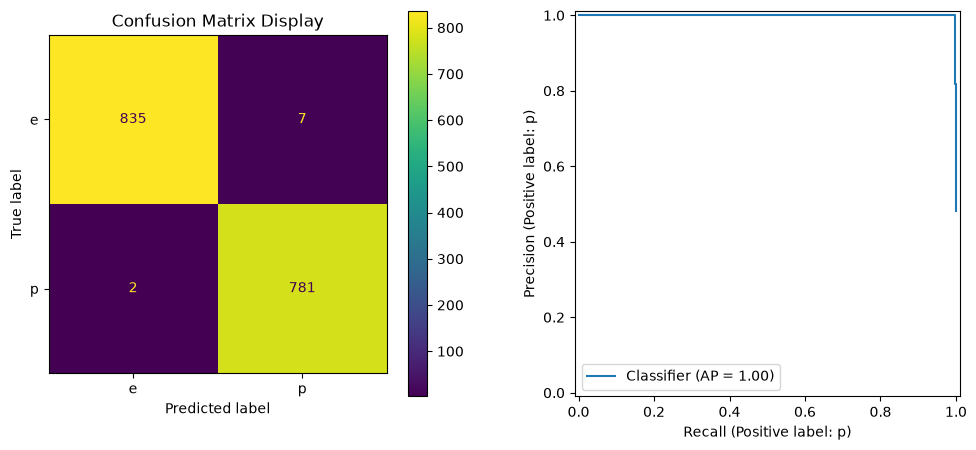

In [135]:
# VISUALIZATIONS

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, PrecisionRecallDisplay

fig, axes = plt.subplots(1,2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(y_test, predictions, ax=axes[0])
axes[0].set_title("Confusion Matrix Display")

PrecisionRecallDisplay.from_predictions(y_test, proba, pos_label='p', ax=axes[1])
